## SETUP AND IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# SIRD model (as in practical)
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Parameters:
    ----------------
    - y:Sequence of float
        Current compartment values [S,I,R,D]
    - t:float
        Current simulation time
    - beta: float
        Transmission rate
    - gamma: float
        Recovery rate
    -mu: float
        Mortality rate

    Returns
    ----------------
    tuple of float
        Derivatives(dS/dt, dI/dt, dR/dt, dD/dt)
    """
    S, I, R, D = y
    N = S + I + R + D

    dSdt = -beta*S*I/N
    dIdt = beta*S*I/N -gamma*I - mu*I
    dRdt = gamma*I
    dDdt = mu*I

    return dSdt, dIdt, dRdt, dDdt

## PART 1. PARAMETER ANALYSIS FUNCTION

In [3]:

def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here

    # Set the recovery rate values of interest
    gamma_values=[0.05, 0.1, 0.15, 0.2, 0.25]

    # Set initial conditions
    S0=N-I0
    R0_initial=0
    D0=0
    y0=[S0,I0,R0_initial, D0]

    # We create an array of daily output points
    t=np.arange(0, simulation_days +1)

    results=[]

    infection_curves={} # for plotting

    # Running model for different values of gamma and collecting the needed statistics
    for gamma in gamma_values:
        solution=odeint(sird_model, y0, t, args=(beta,gamma,mu))

        # extracting solution columns

        S=solution[:,0]
        I=solution[:,1]
        R=solution[:,2]
        D=solution[:,3]

        # Save infection curve for plotting
        infection_curves[gamma]=I
        # extracting the index of highest infections
        peak_idx=np.argmax(I)
        peak_infect=I[peak_idx]
        peak_day=t[peak_idx]
        # Total deaths
        total_deaths=D[-1]
        # Basic reproduction number (as required in the assignment)
        basic_repr_num=beta/gamma
        results.append({"gamma":gamma, "R0": basic_repr_num, "peak_infected":peak_infect, "peak_day":peak_day, "total_deaths":total_deaths})

    # Create results data frame
    results_df=pd.DataFrame(results, columns=["gamma", "R0", "peak_infected", "peak_day", "total_deaths"])
    # formatting the results to ensure we get integer values
    results_df['peak_infected']=(results_df["peak_infected"].round().astype(int))
    results_df["total_deaths"]=(results_df["total_deaths"].round().astype(int))

    # defining a plotting function
    def plot_curves(ax=None, title=None):

        if ax is None:
            fig, ax= plt.subplots(figsize=(10,6))

        for gamma in gamma_values:
            I=infection_curves[gamma]
            R0_value=beta/gamma

            ax.plot(t, I, linewidth=2, label= f"$gamma\\$= {gamma:.2f}, $R_0$={R0_value:.2f}")
        ax.set_xlabel("Time in days", fontsize=12)
        ax.set_ylabel("Number of infected people", fontsize=12)
        if title is None:
            title="Recovery dynamics for SIRD model for different recovery rates"
        ax.set_title(title, fontsize=14, fontweight=15)
        ax.legend(title="Recovery rate")
        ax.grid(True, alpha=0.5)
        ax.set_xlim(0, simulation_days)
        ax.set_ylim(bottom=0)

        return ax

    return results_df, plot_curves



## PART 2: Scenario comparison

In [4]:
# Running the function on both scenarios and unpackin plotting function
scenario_A, plot_A =analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)
scenario_B, plot_B=analyze_recovery_rates(beta=0.2, mu=0.05,N=1000, I0=5, simulation_days=200 )

In [5]:
# Displaying both Data Frames
print("Scenario A")
display(scenario_A)
print("Scenario B")
display(scenario_B)

Scenario A


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.000000,521,21,285
1,0.10,4.000000,340,22,160
2,0.15,2.666667,213,24,103
3,0.20,2.000000,124,27,67
4,0.25,1.600000,63,30,43


Scenario B


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.000000,156,51,399
1,0.10,2.000000,38,66,154
2,0.15,1.333333,5,0,23
3,0.20,1.000000,5,0,5
4,0.25,0.800000,5,0,2


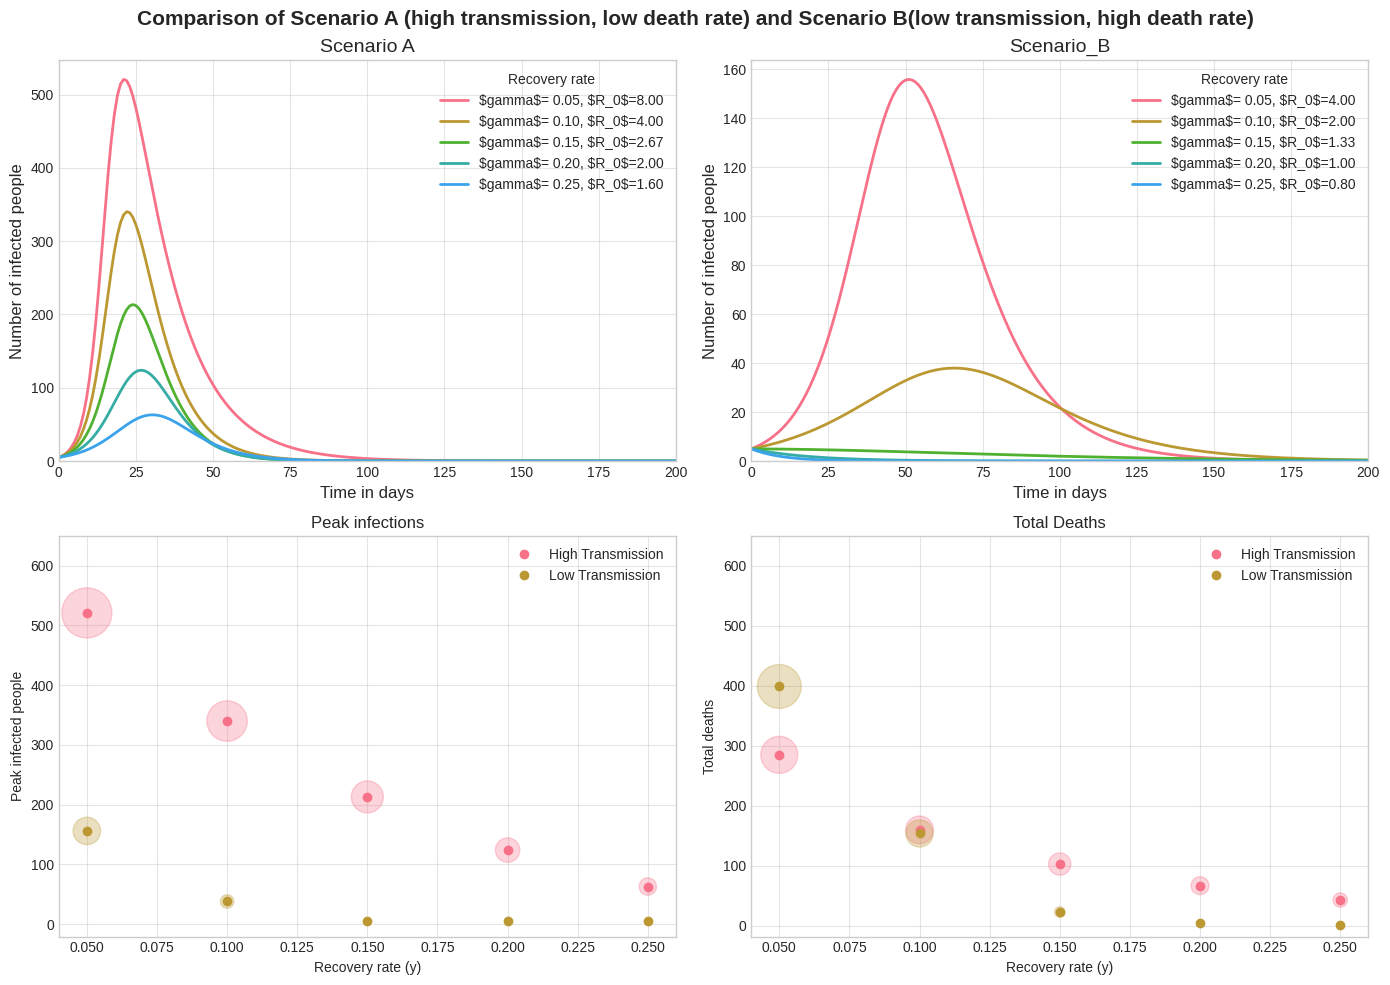

In [6]:
# Comparing both scenarios visually

fig, axes=plt.subplots(2,2, figsize=(14,10))
plot_A(ax=axes[0,0], title="Scenario A")
plot_B(ax=axes[0,1], title="Scenario_B")
axes[1,0].plot(scenario_A["gamma"], scenario_A["peak_infected"], 'o', linewidth=2, label="High Transmission")
axes[1,0].plot(scenario_B["gamma"], scenario_B["peak_infected"], 'o', linewidth=2, label="Low Transmission")

# In the bottom panel we basicaly plot the data points and overlay a scater plot with the radius proportional
# to the number of the category visualised, scaled by 2.5.

axes[1,0].scatter(
    scenario_A["gamma"],
    scenario_A["peak_infected"],
    s=scenario_A["peak_infected"] * 2.5,
    alpha=0.3
)
axes[1,0].scatter(
    scenario_B["gamma"],
    scenario_B["peak_infected"],
    s=scenario_B["peak_infected"] * 2.5,
    alpha=0.3
)
axes[1,0].set_xlabel("Recovery rate (y)")
axes[1,0].set_ylabel("Peak infected people")
axes[1,0].set_title("Peak infections")
axes[1,0].set_ylim(top=650)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.5)

axes[1,1].plot(scenario_A["gamma"], scenario_A["total_deaths"], 'o', linewidth=2, label="High Transmission")
axes[1,1].plot(scenario_B["gamma"], scenario_B["total_deaths"], 'o', linewidth=2, label="Low Transmission")

axes[1,1].scatter(
    scenario_A["gamma"],
    scenario_A["total_deaths"],
    s=scenario_A["total_deaths"] * 2.5,
    alpha=0.3
)
axes[1,1].scatter(
    scenario_B["gamma"],
    scenario_B["total_deaths"],
    s=scenario_B["total_deaths"] * 2.5,
    alpha=0.3
)
axes[1,1].set_xlabel("Recovery rate (y)")
axes[1,1].set_ylabel("Total deaths")
axes[1,1].set_title("Total Deaths")
axes[1,1].set_ylim(top=650)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.5)

plt.suptitle("Comparison of Scenario A (high transmission, low death rate) and Scenario B(low transmission, high death rate)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Public health comparison of Scenario A and Scenario B

Scenario A has higher transmission rate which is cleaarly reflected in the infection curves. For every tested recovery rate scenario A produces larger infected peak than scenario B. At the lowest recovery rate, scenario A leads to a peak of about 521 individuals, which means that more than 50% of the population is simultaneously infected. We have no data no severity of symptons, but that sheer number itself suggets that a pressure on the hospitals and healthcare workers would be significant. To compare, scenario B reaches the peak at around 156 infected people. Furhtermore, in scenario A the epidemic peaks early, between 21 and 30 day, depending on the recovery rate. In scenario B the peak occurs much later, on day 51 for gamma=0.05, and day 66 for gamma = 0.1. So scenario A produces significantly faster and more intense epidemic, which poses challanges for the healthcare system: the rapid rise in infections leaves less time to prepare.

What's important, as the recovery rate increases, the basic reproduction number decreases in both scenarrios, but it remains higher in scenario A for all values of gamma. This means that the infections sread more efficiently in scenario A and outbreak grows faster and affect more people befor recovery  begins to suppress transmission.

It seems therefore that scenario A poses an overall greater threat to public health than scenario B. However, under certain choice of parameters , scenario B demonstrates that a lower-transmission disease is not necessairly less dengerous: when recovery is low it can lead to higher mortality despite much smaller epidemic peak. At gamma=0.05 scenario B produces 399 death (nearly 40% of the ppulation) vs 285 deaths in scenario A.

To sum up,  scenario A is primarily dangerous because of rapid and widespread transmission, leading to large epidemic peaks and a high risk of overwhelming healcare capacity under much wider range of recovery rates. Scenario B is dangerous mostly because of disease severity (low gamma) leading to mupltiple deaths despite lower spreading dynamics.
Overall however, scenario A seem to pose greater danger to the healtcare system.

## Policy Recommendations

### 3.1 Parameter impact analysis

Increasing recovery rate has strong impact beneficial effect on epidemic severity in both scenarios. Higher recovery rate means people leave the infected group quicker and have less time to spread the disease and are less exposed to the mortality processes represented by mu.

#### Impact on peak

 In scenario A, at gamma=0.05, R0 was equal to 8 - increadibly high. Epidemic peaked at day 21 with 521 infected individuals and 285 total deaths. Increasing gamma to 0.1 lowered the peak of infections by 34.7% (from 531 to 340). Increasing gamam further to 0.25 lowers the peak to 63 individuals- a reduction by 87.9%. Scenario B achieves significantly lower peak- 156 infected at gamma=0.05. This number drops down further to 38 by gamma  increase to 0.10, settling at the level of 5 infected people (which is the initial value) for gamma values >= 0.15. At gamma=0.15, the peak number infected remains at the initial value of 5, and the peak occurs on day 0. The same pattern prevails for gamma=0.2 and gamma=0.25, suggesting that under these conditions new infections do not replace infected individuals quickly enough to sustain epidemic growth. Relatively large beta is dominated by the effects of gamma and mu combined.

#### Impact on deaths

 Same pattern is visible in total deaths: at gamma=0.05 scenario A produces 285 deaths, at gamma=0.25 it produces 43 deaths. The reduction is 84.9%. The infected individuals recover quicker so they spend less time at risk of dying. Morover, they can trasmit the disease for a shorter period of time. Scenario B produces 399 deaths at the 0.05 gamma level. The number drops down by 61.4%, to 154 deaths, with gamma increase to 0.10. Another significant drop occurs when gamma is raised to 0.15- 23 deaths. For gamma=0.20 scenario B produces 5 deaths, for 0.25- only 2 deaths, which is below the initially infected individuals. In contrast, evena at gamma=0.25 scenario A still produces significant number of 43 deaths


#### Effect on duration

The epidemic curves become smaller and narrower as gamma increases. Increasing recovery rate shortens the period during which substantial number of individuals remains in the population. As suggested by our plots, the epidemic lasts longest at low recovery rates and becomes much shorter as recovery improves. Moreover, the peak day moves slightly later as gamma increases. In scenario A the peak is between day 21 (for gamma=0.05) and 30 (gamma=0.25).  For scenario B the peak occures much later: on day 55 (gamma=0.05) or 66 (gamma=0.1). As mentioned above, for values of gamma greater than 0.15, the peak occurs on day 0- there is no visible outbreak. The outbreak becomes much smaller and may grow more slowly before declining.


To sum up, increasing gamma lowers the basic reproduction number, reduces epidemic peak, shifts it later in time and lowers the mortality. In case of a disease with high transmission rate and low mortality (scenario A) increasing recovery rate at every level can produce visible beneficial effects. In case of a disease with lower transmission rate, but with higher mortality, the most substantive gains are produced when raising the level of gamma between 0.05-0.15.



### Intervention analysis
